[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nikbaya/smartbiomed_practicals_2026/blob/main/session3/run.ipynb)

# Session 3: Complexities of GWAS — Population Structure & Relatedness

**Timing**: ~60 minutes (Parts 1–4 ~45 min; challenges for fast finishers).

**Dataset**: a simulated **"All of Us"-style** diverse cohort (~2,000 participants) plus a small
**"1000 Genomes"-style reference panel** (~75 individuals per continental group, with known labels),
each genotyped at 20,000 independent SNPs.
- `G`        : the diverse cohort we analyse.
- `G_ref`    : the labelled reference panel (superpopulations AFR, AMR, EAS, EUR, SAS).
- `y_strat`  : a cohort phenotype confounded **purely by ancestry** (environmental — no causal variant).
- `y_clean`  : a cohort phenotype with a few **true causal variants** and no confounding.

Everything (PCA, GWAS) is built from scratch with NumPy; the only "black box" we hand you is a
ready-made random-forest classifier for the ancestry-assignment step.


In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# SETUP — run once. Downloads the data (on Colab) and defines run_gwas + helpers.
# ─────────────────────────────────────────────────────────────────────────────
import os, numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 80, 'font.size': 11})

# Locate the data directory, downloading from GitHub if needed (e.g. on Colab).
import os, urllib.request
_NEED = ['pca_data.npz']
_LFS  = {'gwas_data.npz', 'sumstats_real.npz', 'pca_data.npz', 'finemap_data.npz'}   # Git LFS
def _has_all(d):
    return d and all(os.path.exists(os.path.join(d, f)) for f in _NEED)
DATA_DIR = next((d for d in ('../data', 'data') if _has_all(d)), None)
if DATA_DIR is None:
    DATA_DIR = 'data'; os.makedirs(DATA_DIR, exist_ok=True)
    for _f in _NEED:
        _dest = os.path.join(DATA_DIR, _f)
        if os.path.exists(_dest):
            continue
        _base = ('https://media.githubusercontent.com/media' if _f in _LFS
                 else 'https://raw.githubusercontent.com')
        _url = f'{_base}/nikbaya/smartbiomed_practicals_2026/main/data/{_f}'
        print(f'Downloading {_f} from GitHub ...')
        urllib.request.urlretrieve(_url, _dest)

data = np.load(os.path.join(DATA_DIR, 'pca_data.npz'), allow_pickle=True)

# ── The diverse cohort we analyse ("All of Us"-style) ────────────────────────
G              = data['G'].astype(np.float32)   # (N_cohort, M)  genotypes 0/1/2
y_strat        = data['y_strat']                # ancestry-confounded phenotype (no genetics)
y_clean        = data['y_clean']                # phenotype with true causal variants
causal_idx     = data['causal_idx']             # true causal SNP indices for y_clean
rel_pairs      = data['rel_pairs']              # injected sibling pairs (row indices into G)
true_anc       = data['true_anc']               # (N_cohort, 5) TRUE ancestry proportions (answer key)
age            = data['age']
sex            = data['sex']

# ── The labelled reference panel ("1000 Genomes"-style) ──────────────────────
G_ref          = data['G_ref'].astype(np.float32)   # (N_ref, M) genotypes 0/1/2
ref_pop        = data['ref_pop']                    # superpopulation index for each reference person
superpop_names = data['superpop_names']             # ['AFR', 'AMR', 'EAS', 'EUR', 'SAS']

n_cohort = G.shape[0]
n_ref    = G_ref.shape[0]
n_snps   = G.shape[1]
print(f"Cohort:    {n_cohort:,} individuals x {n_snps:,} SNPs")
print(f"Reference: {n_ref:,} individuals, "
      f"{len(superpop_names)} superpopulations ({list(superpop_names)})")

def run_gwas(y, G, covars=None, chunk=5_000):
    """
    Vectorised OLS GWAS: regress phenotype y on each column of G.
    Processes variants in batches to keep peak memory usage low.

    Parameters
    ----------
    y      : (N,)    phenotype (will be mean-centred internally)
    G      : (N, M)  genotype matrix (0/1/2), NaN = missing (treated as mean)
    covars : (N, k)  covariate matrix (optional); age and sex recommended
    chunk  : int     variants per batch (default 5,000)

    Returns
    -------
    betas  : (M,)  per-variant OLS effect size estimate
    ses    : (M,)  standard error of beta
    pvals  : (M,)  two-sided p-value
    """
    N, M = G.shape
    if covars is None:
        C = np.ones((N, 1))
    else:
        C = np.column_stack([np.ones(N), covars])

    # Residualise y on covariates once (cheap)
    Q, _  = np.linalg.qr(C, mode='reduced')
    y_r   = y - Q @ (Q.T @ y)
    ss_y  = float(np.dot(y_r, y_r))
    n_df  = N - C.shape[1] - 1

    betas = np.empty(M); ses = np.empty(M)

    for s in range(0, M, chunk):
        e    = min(s + chunk, M)
        G_c  = G[:, s:e].astype(float)
        mu   = np.nanmean(G_c, axis=0)
        ri, ci = np.where(np.isnan(G_c)); G_c[ri, ci] = mu[ci]   # mean-impute
        G_r  = G_c - Q @ (Q.T @ G_c)                              # residualise
        ss_G = (G_r**2).sum(0)
        b    = G_r.T @ y_r / ss_G
        betas[s:e] = b
        rss  = ss_y - b**2 * ss_G
        ses[s:e]   = np.sqrt(np.clip(rss, 0, None) / n_df / ss_G)

    t_stats = betas / (ses + 1e-300)
    pvals   = 2 * stats.t.sf(np.abs(t_stats), df=n_df)
    return betas, ses, pvals

def qq_plot(pvals, ax=None, color='steelblue', label=''):
    """QQ plot of -log10(p) vs the uniform-null expectation, x-axis truncated."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    n   = len(pvals)
    obs = -np.log10(np.sort(pvals) + 1e-300)
    exp = -np.log10(np.arange(1, n+1) / (n+1))
    ax.scatter(exp, obs, s=4, alpha=0.5, color=color, label=label)
    ax.plot([0, exp.max()], [0, exp.max()], 'r--', lw=1); ax.set_xlim(0, exp.max())
    ax.set_xlabel(r'Expected $-\log_{10}p$'); ax.set_ylabel(r'Observed $-\log_{10}p$')
    if label: ax.legend(fontsize=8)
    return ax

def lambda_gc(pvals):
    """Genomic-control inflation factor: 1.0 means no inflation."""
    chi2 = stats.chi2.isf(np.clip(pvals, 1e-300, 1), df=1)
    return np.median(chi2) / stats.chi2.ppf(0.5, df=1)

print("Setup ready: run_gwas(), qq_plot(), lambda_gc().")


/Users/nbaya/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Cohort:    2,012 individuals x 19,974 SNPs
Reference: 375 individuals, 5 superpopulations (['AFR', 'AMR', 'EAS', 'EUR', 'SAS'])
Setup ready: run_gwas(), qq_plot(), lambda_gc().


## Part 1: Seeing population stratification

If allele frequencies differ between ancestral groups **and** the phenotype mean differs between
those groups (for *environmental* reasons), then *every* ancestry-informative variant will look
associated — even with no causal effect at all. This is **confounding by population structure**.

`y_strat` was generated with **no genetic effect** — its mean only differs by ancestry. Run a
GWAS and see what the QQ plot / $\lambda_{GC}$ look like.


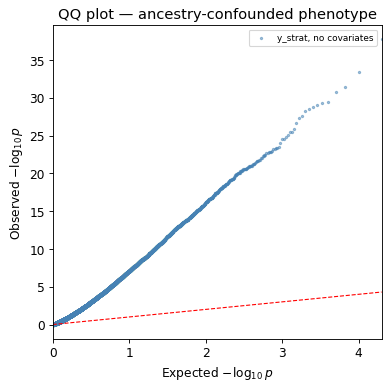

lambda_GC = 10.92
'Hits' at p < 5e-8: 1,889  — all spurious (ancestry confounding).


In [2]:
# Run the GWAS with no covariates: every ancestry-informative SNP picks up the ancestry-driven
# difference in phenotype means.
betas, std_errors, pvalues_strat = run_gwas(y_strat, G)

fig, ax = plt.subplots(figsize=(5, 5))
qq_plot(pvalues_strat, ax=ax, label='y_strat, no covariates')
ax.set_title('QQ plot — ancestry-confounded phenotype')
plt.tight_layout(); plt.show()

n_hits = (pvalues_strat < 5e-8).sum()
print(f"lambda_GC = {lambda_gc(pvalues_strat):.2f}")
print(f"'Hits' at p < 5e-8: {n_hits:,}  — all spurious (ancestry confounding).")


## Part 2: Principal Component Analysis (PCA) from scratch

PCA finds the axes of greatest genetic variation across individuals — which, for structured
samples, are the **ancestry axes**. We compute it directly from the standardised genotype matrix
with a singular value decomposition (SVD); no specialised package needed.

If $Z$ is the (individuals × SNPs) standardised genotype matrix, then $Z = U S V^\top$ and the
**principal-component scores** are the columns of $U S$. The top few capture ancestry.

We stack the **reference panel on top of the cohort** and run PCA on everyone together, so that
both live in the *same* PC space. We then colour the reference individuals by their known
superpopulation and draw the cohort in grey — exactly the kind of plot you see for All of Us.


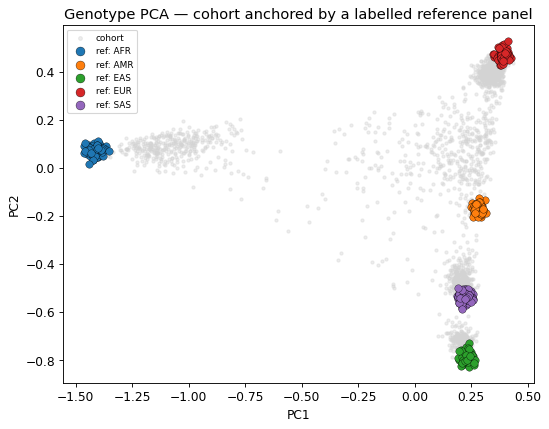

In [3]:
genotypes_all = np.vstack([G_ref, G])
genotype_mean = genotypes_all.mean(axis=0)
genotype_sd   = genotypes_all.std(axis=0) + 1e-8
Z = (genotypes_all - genotype_mean) / genotype_sd

n_total = genotypes_all.shape[0]
U, S, Vt = np.linalg.svd(Z / np.sqrt(n_total), full_matrices=False)
PC = U * S

PC_ref    = PC[:n_ref]
PC_cohort = PC[n_ref:]

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(PC_cohort[:, 0], PC_cohort[:, 1], s=8, alpha=0.4, color='lightgrey', label='cohort')
for group_index, group_name in enumerate(superpop_names):
    is_this_group = ref_pop == group_index
    ax.scatter(PC_ref[is_this_group, 0], PC_ref[is_this_group, 1],
               s=45, edgecolor='black', lw=0.3, label=f'ref: {group_name}')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Genotype PCA — cohort anchored by a labelled reference panel')
ax.legend(fontsize=8, markerscale=1.2); plt.tight_layout(); plt.show()


## Part 3: Assigning continental ancestry with a reference panel

In a biobank we rarely *know* anyone's ancestry — we only have the genotypes. The standard trick is
exactly what we set up in Part 2: project everyone into PC space, then **use the labelled reference
panel to name the clusters**.

A convenient way to turn "near which reference cluster?" into an automatic label is a
**classifier**. We train a **random forest** on the reference individuals (features = their top PCs,
labels = their superpopulation), then ask it to predict a superpopulation for each cohort member.

Crucially, the classifier also reports a **probability** for each prediction. Admixed individuals
sit *between* clusters, so no single superpopulation gets a high probability — we use a
**confidence threshold** to leave those people **unassigned** rather than forcing a wrong label.


In [4]:
from sklearn.ensemble import RandomForestClassifier

n_pc = 10
reference_features = PC_ref[:, :n_pc]
reference_labels   = ref_pop

classifier = RandomForestClassifier(n_estimators=300, random_state=0)
classifier.fit(reference_features, reference_labels)

cohort_features        = PC_cohort[:, :n_pc]
predicted_probability  = classifier.predict_proba(cohort_features)
best_probability       = predicted_probability.max(axis=1)
predicted_group_index  = predicted_probability.argmax(axis=1)

CONFIDENCE_THRESHOLD = 0.80
is_confident = best_probability >= CONFIDENCE_THRESHOLD

assigned_label = np.where(is_confident,
                          superpop_names[predicted_group_index],
                          'Unassigned')

labels_unique, label_counts = np.unique(assigned_label, return_counts=True)
print(f"Confidence threshold = {CONFIDENCE_THRESHOLD}")
for label, count in zip(labels_unique, label_counts):
    print(f"  {label:11s}: {count:5d}  ({100*count/n_cohort:4.1f}%)")


Confidence threshold = 0.8
  AFR        :   360  (17.9%)
  AMR        :    47  ( 2.3%)
  EAS        :   184  ( 9.1%)
  EUR        :   499  (24.8%)
  SAS        :   251  (12.5%)
  Unassigned :   671  (33.3%)


Now **re-draw the PCA, colouring each cohort member by its assigned superpopulation** (and leaving
the unassigned individuals grey). This is the figure a biobank publishes to describe its cohort.


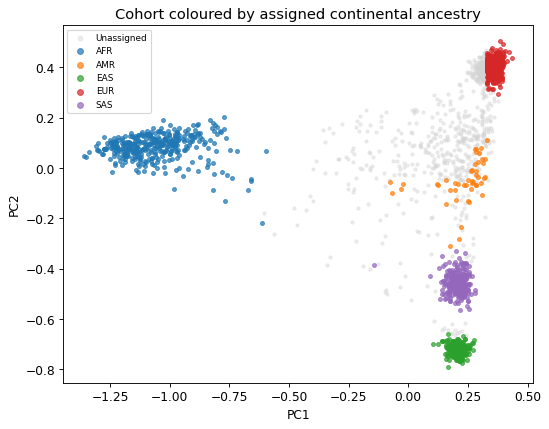

In [5]:
fig, ax = plt.subplots(figsize=(7, 5.5))
unassigned = assigned_label == 'Unassigned'
ax.scatter(PC_cohort[unassigned, 0], PC_cohort[unassigned, 1],
           s=8, alpha=0.4, color='lightgrey', label='Unassigned')
for group_name in superpop_names:
    in_group = assigned_label == group_name
    ax.scatter(PC_cohort[in_group, 0], PC_cohort[in_group, 1],
               s=12, alpha=0.7, label=str(group_name))
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Cohort coloured by assigned continental ancestry')
ax.legend(fontsize=8, markerscale=1.5); plt.tight_layout(); plt.show()


## Part 4: Correcting stratification with PCs

Including the top PCs as **covariates** soaks up the ancestry signal, so the spurious associations
disappear and $\lambda_{GC}$ returns to ~1. Crucially, **true** signal survives — re-run the
clean phenotype `y_clean` (which has real causal variants) and check its hits are still there.

(We use `PC_cohort` — the cohort's own rows of the PCA — as the covariates.)


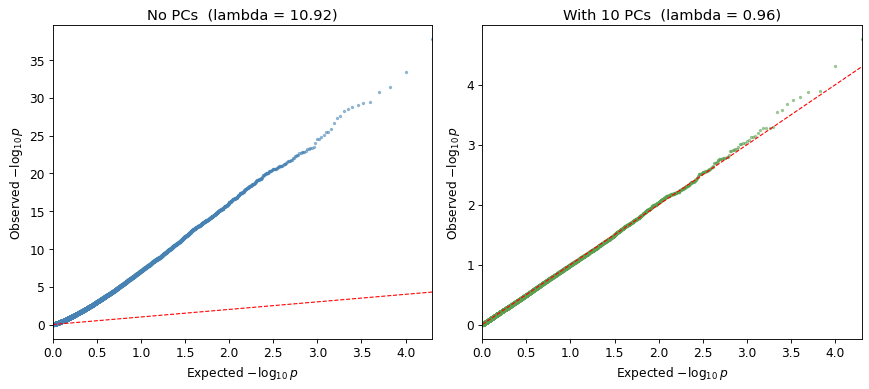

y_clean hits at p < 5e-8 (with PCs): 3
  true causal SNPs recovered: 3/3


In [6]:
n_pc = 10
ancestry_covariates = PC_cohort[:, :n_pc]

_, _, pvalues_strat_pc = run_gwas(y_strat, G, covars=ancestry_covariates)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
qq_plot(pvalues_strat, ax=axes[0])
axes[0].set_title(f'No PCs  (lambda = {lambda_gc(pvalues_strat):.2f})')
qq_plot(pvalues_strat_pc, ax=axes[1], color='#59a14f')
axes[1].set_title(f'With {n_pc} PCs  (lambda = {lambda_gc(pvalues_strat_pc):.2f})')
plt.tight_layout(); plt.show()

_, _, pvalues_clean = run_gwas(y_clean, G, covars=ancestry_covariates)
n_recovered = sum(pvalues_clean[c] < 5e-8 for c in causal_idx)
print(f"y_clean hits at p < 5e-8 (with PCs): {(pvalues_clean < 5e-8).sum()}")
print(f"  true causal SNPs recovered: {n_recovered}/{len(causal_idx)}")


---

## Challenge Questions


### Challenge 1: Who gets left "Unassigned"? — ~12 min

The classifier left some cohort members unlabelled. Are these really the **admixed** individuals?
We can check, because the simulation stored each person's **true ancestry proportions** (`true_anc`,
columns AFR, AMR, EAS, EUR, SAS). A person dominated by one ancestry has a *max* proportion near 1;
an admixed person's largest proportion is much smaller. Then explore how the **threshold** trades
off coverage against confidence.


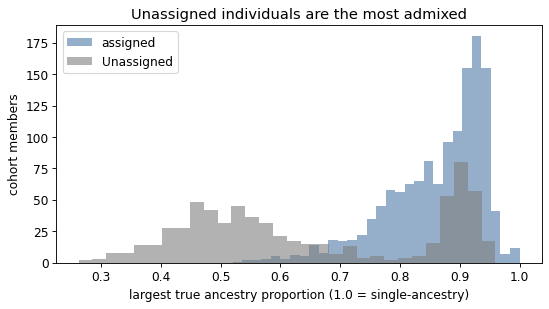

Mean dominant ancestry — assigned: 0.86, unassigned: 0.65


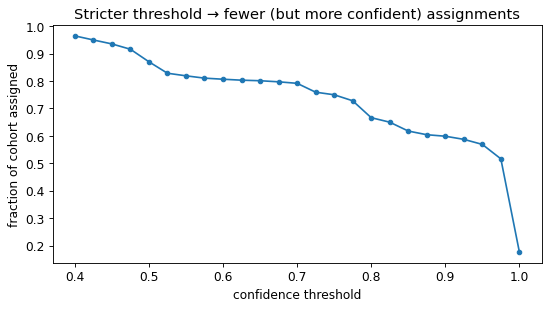

In [7]:
dominant_ancestry_fraction = true_anc.max(axis=1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(dominant_ancestry_fraction[~unassigned], bins=30, alpha=0.6, label='assigned', color='#4e79a7')
ax.hist(dominant_ancestry_fraction[ unassigned], bins=30, alpha=0.6, label='Unassigned', color='grey')
ax.set_xlabel('largest true ancestry proportion (1.0 = single-ancestry)')
ax.set_ylabel('cohort members'); ax.legend()
ax.set_title('Unassigned individuals are the most admixed'); plt.tight_layout(); plt.show()
print(f"Mean dominant ancestry — assigned: {dominant_ancestry_fraction[~unassigned].mean():.2f}, "
      f"unassigned: {dominant_ancestry_fraction[unassigned].mean():.2f}")

thresholds = np.linspace(0.4, 1.0, 25)
fraction_assigned = [ (best_probability >= t).mean() for t in thresholds ]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, fraction_assigned, marker='o', ms=4)
ax.set_xlabel('confidence threshold'); ax.set_ylabel('fraction of cohort assigned')
ax.set_title('Stricter threshold → fewer (but more confident) assignments')
plt.tight_layout(); plt.show()
# Admixed people are dropped first — a real cost, since ancestry-restricted analyses then
# systematically exclude them.


### Challenge 2: Relatedness and the GRM — ~12 min

Close relatives share long genomic segments, which (like ancestry) violates the independence GWAS
assumes. The **genetic relatedness matrix** $\text{GRM} = \frac{1}{M} Z Z^\top$ quantifies it.
A few **sibling pairs** were hidden in the cohort — find them, and think about why mixed models exist.


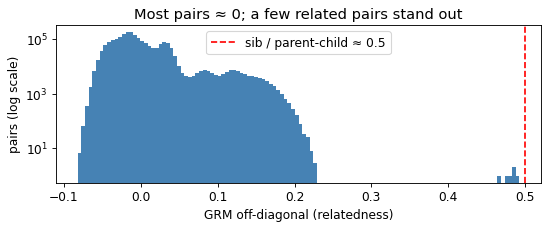

Injected sibling pairs (relatedness should be ≈ 0.5):
  rows 2000,2001: GRM = 0.49
  rows 2002,2003: GRM = 0.48
  rows 2004,2005: GRM = 0.48
  rows 2006,2007: GRM = 0.48
  rows 2008,2009: GRM = 0.47
  rows 2010,2011: GRM = 0.49


In [8]:
Z_cohort = (G - G.mean(axis=0)) / (G.std(axis=0) + 1e-8)
GRM = Z_cohort @ Z_cohort.T / n_snps

off_diagonal = GRM[np.triu_indices(n_cohort, k=1)]
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(off_diagonal, bins=120, color='steelblue'); ax.set_yscale('log')
ax.axvline(0.5, color='red', ls='--', label='sib / parent-child ≈ 0.5')
ax.set_xlabel('GRM off-diagonal (relatedness)'); ax.set_ylabel('pairs (log scale)'); ax.legend()
ax.set_title('Most pairs ≈ 0; a few related pairs stand out'); plt.tight_layout(); plt.show()
print("Injected sibling pairs (relatedness should be ≈ 0.5):")
for person_i, person_j in rel_pairs:
    print(f"  rows {person_i},{person_j}: GRM = {GRM[person_i, person_j]:.2f}")
# Relatives share segments → correlated residuals → inflated statistics. A linear mixed model
# puts the GRM in the covariance of a random effect, accounting for this structure.
